<a href="https://colab.research.google.com/github/sinayavarian/ML-practice/blob/main/Sina_Preprocessing_05_Simple_Imputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SimpleImputer
### This notebook outlines the usage of Simple Imputer (Univariate Imputation).
### Simple Imputer substitutes missing values statistics (mean, median, ...)
#### Dataset: [https://github.com/subashgandyer/datasets/blob/main/heart_disease.csv]

**Demographic**
- Sex: male or female(Nominal)
- Age: Age of the patient;(Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

**Behavioral**
- Current Smoker: whether or not the patient is a current smoker (Nominal)
- Cigs Per Day: the number of cigarettes that the person smoked on average in one day.(can be considered continuous as one can have any number of cigarettes, even half a cigarette.)

**Medical(history)**
- BP Meds: whether or not the patient was on blood pressure medication (Nominal)
- Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
- Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
- Diabetes: whether or not the patient had diabetes (Nominal)

**Medical(current)**
- Tot Chol: total cholesterol level (Continuous)
- Sys BP: systolic blood pressure (Continuous)
- Dia BP: diastolic blood pressure (Continuous)
- BMI: Body Mass Index (Continuous)
- Heart Rate: heart rate (Continuous - In medical research, variables such as heart rate though in fact discrete, yet are considered continuous because of large number of possible values.)
- Glucose: glucose level (Continuous)

**Predict variable (desired target)**
- 10 year risk of coronary heart disease CHD (binary: “1”, means “Yes”, “0” means “No”)

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/refs/heads/main/heart_disease.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


### How many Categorical variables in the dataset?

In [3]:
df.select_dtypes(include=['object']).shape[1]

0

### How many Missing values in the dataset?
Hint: df.Series.isna( ).sum( )

In [4]:
df.isna().sum().sum()


np.int64(645)

In [5]:
for i in range(len(df.columns)):
    missing_data = df.iloc[:, i].isna().sum()

    perc = missing_data / len(df) * 100
    print(f'Feature {i+1} >> Missing entries: {missing_data}  |  Percentage: {round(perc, 2)}')

Feature 1 >> Missing entries: 0  |  Percentage: 0.0
Feature 2 >> Missing entries: 0  |  Percentage: 0.0
Feature 3 >> Missing entries: 105  |  Percentage: 2.48
Feature 4 >> Missing entries: 0  |  Percentage: 0.0
Feature 5 >> Missing entries: 29  |  Percentage: 0.68
Feature 6 >> Missing entries: 53  |  Percentage: 1.25
Feature 7 >> Missing entries: 0  |  Percentage: 0.0
Feature 8 >> Missing entries: 0  |  Percentage: 0.0
Feature 9 >> Missing entries: 0  |  Percentage: 0.0
Feature 10 >> Missing entries: 50  |  Percentage: 1.18
Feature 11 >> Missing entries: 0  |  Percentage: 0.0
Feature 12 >> Missing entries: 0  |  Percentage: 0.0
Feature 13 >> Missing entries: 19  |  Percentage: 0.45
Feature 14 >> Missing entries: 1  |  Percentage: 0.02
Feature 15 >> Missing entries: 388  |  Percentage: 9.16
Feature 16 >> Missing entries: 0  |  Percentage: 0.0


### Bonus: Visual representation of missing values

<Axes: >

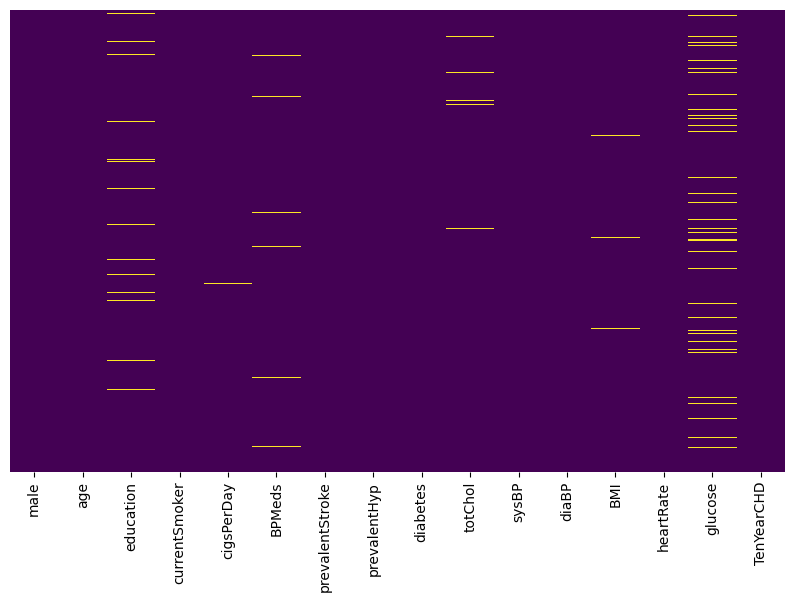

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)

### Import SimpleImputer

In [7]:
from sklearn.impute import SimpleImputer


### Create SimpleImputer object with 'mean' strategy

In [8]:
imputer = SimpleImputer(strategy='mean')

### Optional - converting df into numpy array (There is a way to directly impute from dataframe as well)

In [9]:
data = df.values

In [10]:
X = data[:, :-1]
y = data[:, -1]

### Fit the imputer model on dataset to calculate statistic for each column



In [11]:
imputer.fit(X)


SimpleImputer()

### Trained imputer model is applied to dataset to create a copy of dataset with all filled missing values from the calculated statistic using transform( )

In [12]:
X_transform = imputer.transform(X)

### Sanity Check: Whether missing values are filled or not




In [13]:
Missing_cells = np.isnan(X_transform).sum()


In [14]:
print("Missing cells: ", Missing_cells)

Missing cells:  0


### Let's try to visualize the missing values.

<Axes: >

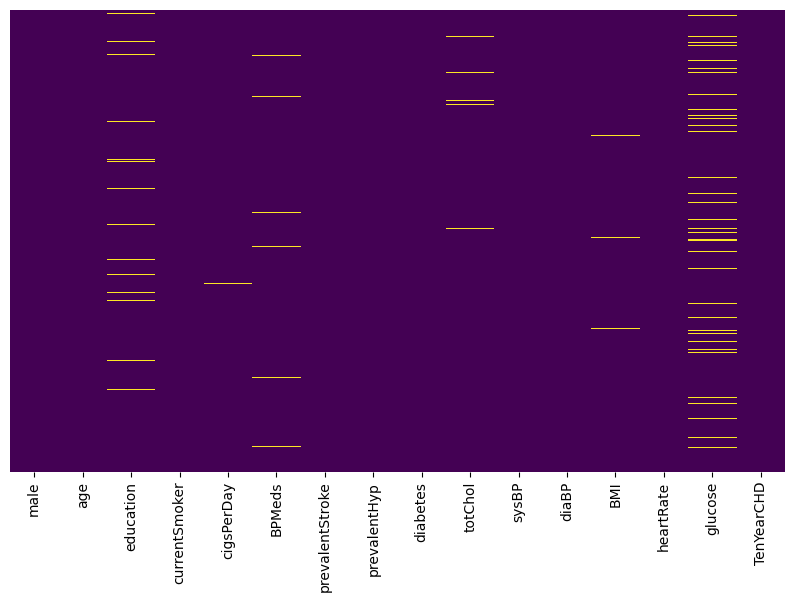

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isna(), cbar=False, cmap='viridis', yticklabels=False)

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(X_transform.isna(), cbar=False, cmap='viridis', yticklabels=False)

AttributeError: 'numpy.ndarray' object has no attribute 'isna'

<Figure size 1000x600 with 0 Axes>

### What's the issue here?
#### Hint: Heatmap needs a DataFrame and not a Numpy Array

In [17]:
df_transform = pd.DataFrame(X_transform)
df_transform


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.0,39.0,4.0,0.0,0.0,0.00000,0.0,0.0,0.0,195.0,106.0,70.0,26.97,80.0,77.000000
1,0.0,46.0,2.0,0.0,0.0,0.00000,0.0,0.0,0.0,250.0,121.0,81.0,28.73,95.0,76.000000
2,1.0,48.0,1.0,1.0,20.0,0.00000,0.0,0.0,0.0,245.0,127.5,80.0,25.34,75.0,70.000000
3,0.0,61.0,3.0,1.0,30.0,0.00000,0.0,1.0,0.0,225.0,150.0,95.0,28.58,65.0,103.000000
4,0.0,46.0,3.0,1.0,23.0,0.00000,0.0,0.0,0.0,285.0,130.0,84.0,23.10,85.0,85.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1.0,50.0,1.0,1.0,1.0,0.00000,0.0,1.0,0.0,313.0,179.0,92.0,25.97,66.0,86.000000
4234,1.0,51.0,3.0,1.0,43.0,0.00000,0.0,0.0,0.0,207.0,126.5,80.0,19.71,65.0,68.000000
4235,0.0,48.0,2.0,1.0,20.0,0.02963,0.0,0.0,0.0,248.0,131.0,72.0,22.00,84.0,86.000000
4236,0.0,44.0,1.0,1.0,15.0,0.00000,0.0,0.0,0.0,210.0,126.5,87.0,19.16,86.0,81.966753


<Axes: >

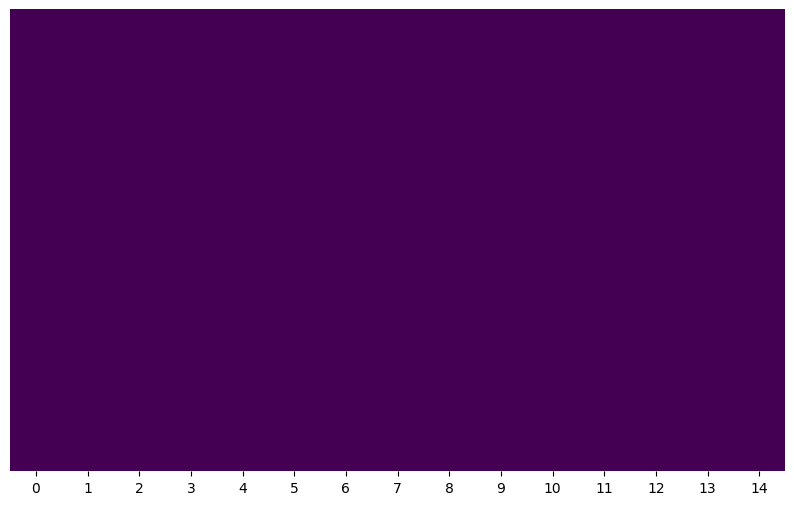

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df_transform.isna(), cbar=False, cmap='viridis', yticklabels=False)

# Check if these datasets contain missing data
### Load the datasets

In [21]:
from google.colab import files
uploaded = files.upload()

Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving Y_test.csv to Y_test.csv
Saving Y_train.csv to Y_train.csv


In [22]:
X_train = pd.read_csv("X_train.csv")
Y_train = pd.read_csv("Y_train.csv")
Y_test = pd.read_csv("Y_test.csv")
X_test = pd.read_csv("X_test.csv")

In [23]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((384, 12), (384, 1), (96, 12), (96, 1))

<Axes: >

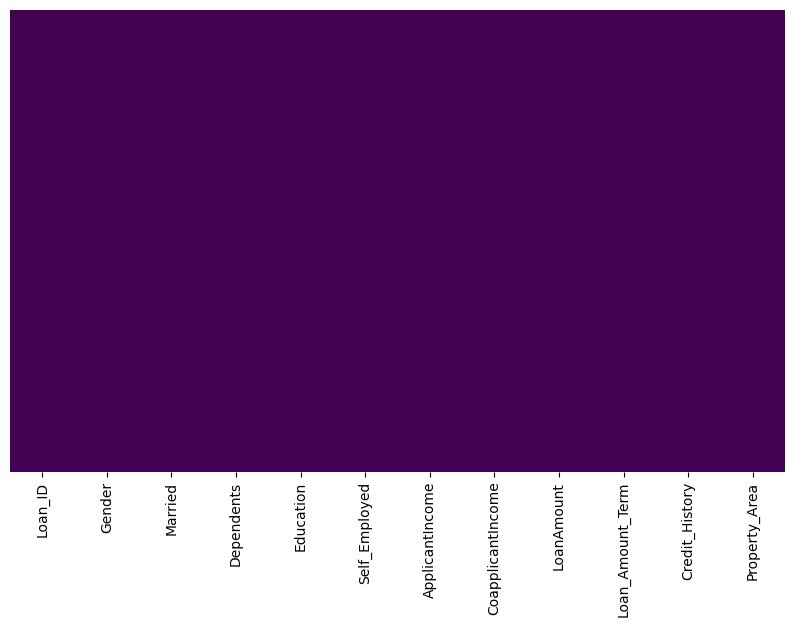

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(X_train.isna(), cbar=False, cmap='viridis', yticklabels=False)

### Is there missing data in this dataset???

In [25]:
X_train.isna().sum().sum()

np.int64(0)

# Build a Logistic Regression model Without imputation

In [26]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/refs/heads/main/heart_disease.csv")
X = df[df.columns[:-1]]
y = df[df.columns[-1]]

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [28]:
model = LogisticRegression()

In [29]:
model.fit(X,y)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Drop all rows with missing entries - Build a Logistic Regression model and benchmark the accuracy

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [31]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/refs/heads/main/heart_disease.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [32]:
df.shape

(4238, 16)

### Drop rows with missing values

In [33]:
df.dropna(inplace=True)
df.shape

(3656, 16)

### Split dataset into X and y

In [34]:
data = df.values
X = data[:, :-1]
y = data[:, -1]
X.shape

(3656, 15)

In [ ]:
y.shape

### Create a pipeline with model parameter

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])


### Create a RepeatedStratifiedKFold with 10 splits and 3 repeats and
random_state=1

In [36]:
from sklearn.model_selection import RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=1
)


### Call cross_val_score with pipeline, X, y, accuracy metric and cv

In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipe,
    X,
    y,
    scoring='accuracy',
    cv=cv
)

scores.mean()


np.float64(0.8534832946577837)

In [38]:
scores

array([0.85245902, 0.86065574, 0.85245902, 0.8579235 , 0.84972678,
       0.8442623 , 0.85205479, 0.8739726 , 0.84931507, 0.85479452,
       0.86612022, 0.84972678, 0.8579235 , 0.8442623 , 0.84699454,
       0.84699454, 0.85753425, 0.84931507, 0.85479452, 0.84931507,
       0.85245902, 0.86065574, 0.85245902, 0.84153005, 0.87431694,
       0.84699454, 0.85479452, 0.84931507, 0.85753425, 0.84383562])

### Print the Mean Accuracy and Standard Deviation from scores

In [39]:
print(f"Mean Accuracy: {round(np.mean(scores), 3)}  | Std: {round(np.std(scores), 3)}")

Mean Accuracy: 0.853  | Std: 0.008


# Build a Logistic Regression model with SimpleImputer Mean Strategy

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [41]:
df=pd.read_csv("https://raw.githubusercontent.com/subashgandyer/datasets/refs/heads/main/heart_disease.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


### Split dataset into X and y

In [42]:
df.shape

(4238, 16)

In [43]:
data = df.values
X = data[:, :-1]
y = data[:, -1]
X.shape

(4238, 15)

In [44]:
y.shape

(4238,)

### Create a SimpleImputer with mean strategy

In [45]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')


### Create a Logistic Regression model

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)


:### Create a pipeline with impute and model parameters

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])


### Create a RepeatedStratifiedKFold with 10 splits and 3 repeats and random_state=1

In [51]:
from sklearn.model_selection import RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=1
)


### Call cross_val_score with pipeline, X, y, accuracy metric and cv

In [52]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline,
    X,
    y,
    scoring='accuracy',
    cv=cv
)

scores.mean()


np.float64(0.8545720148088674)

In [53]:
scores

array([0.85377358, 0.85613208, 0.8490566 , 0.85377358, 0.86320755,
       0.85613208, 0.84669811, 0.85377358, 0.86288416, 0.85815603,
       0.85377358, 0.84669811, 0.84433962, 0.86084906, 0.84669811,
       0.86320755, 0.85377358, 0.85613208, 0.85815603, 0.86524823,
       0.85613208, 0.85849057, 0.85141509, 0.84433962, 0.8490566 ,
       0.85141509, 0.8490566 , 0.86320755, 0.85579196, 0.85579196])

### Print the Mean Accuracy and Standard Deviation

In [54]:
print(f"Mean Accuracy: {round(np.mean(scores), 3)}  | Std: {round(np.std(scores), 3)}")

Mean Accuracy: 0.855  | Std: 0.006


### Which accuracy is better?
- Dropping missing values
- SimpleImputer with Mean Strategy

Accuracy of SimpleImputer with Mean Strategy is better

# SimpleImputer Mean - Benchmark after Mean imputation with RandomForest

### Import libraries

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

### Create a SimpleImputer with mean strategy

In [57]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

### Create a RandomForest model

In [59]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

### Create a pipeline

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


pipeline = Pipeline(steps=[
    ('imputer', imputer),
    ('model', model)
])

### Create RepeatedStratifiedKFold

In [61]:
from sklearn.model_selection import RepeatedStratifiedKFold

cv = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=3,
    random_state=1
)

### Create Cross_val_score

In [62]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipeline,
    X,
    y,
    scoring='accuracy',
    cv=cv
)

scores.mean()


np.float64(0.8493812911667186)

### Print Mean Accuracy and Standard Deviation

In [63]:
print(f"Mean Accuracy: {round(np.mean(scores), 3)}  | Std: {round(np.std(scores), 3)}")

Mean Accuracy: 0.849  | Std: 0.006


# Assignment
# Run experiments with different Strategies and different algorithms

## STRATEGIES
- Mean
- Median
- Most_frequent
- Constant

## ALGORITHMS
- Logistic Regression
- KNN
- Random Forest
- SVM
- Any other algorithm of your choice

#### Hint: Collect the pipeline creation, KFold, and Cross_Val_Score inside a for loop and iterate over different strategies in a list and different algorithms in a list

In [64]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

strategies = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "most_frequent": SimpleImputer(strategy="most_frequent"),
    "constant": SimpleImputer(strategy="constant", fill_value=0),
}


models = {
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=1, n_jobs=-1),
    "SVM(RBF)": SVC(kernel="rbf"),

}

results = []

for strat_name, imputer in strategies.items():
    for model_name, model in models.items():

        steps = [("imputer", imputer)]

        if model_name in ["LogisticRegression", "KNN", "SVM(RBF)"]:
            steps.append(("scaler", StandardScaler()))

        steps.append(("model", model))

        pipe = Pipeline(steps=steps)

        scores = cross_val_score(pipe, X, y, scoring="accuracy", cv=cv, n_jobs=-1)
        results.append({
            "Strategy": strat_name,
            "Algorithm": model_name,
            "Accuracy_mean": scores.mean(),
            "Accuracy_std": scores.std(),
        })

df_results = pd.DataFrame(results).sort_values(by="Accuracy_mean", ascending=False)
df_results.head(10)


,Strategy,Algorithm,Accuracy_mean,Accuracy_std
8,most_frequent,LogisticRegression,0.854729,0.005773
0,mean,LogisticRegression,0.854572,0.005802
4,median,LogisticRegression,0.854493,0.005828
12,constant,LogisticRegression,0.853706,0.005733
10,most_frequent,RandomForest,0.849695,0.006044
2,mean,RandomForest,0.849459,0.006182
6,median,RandomForest,0.849145,0.005018
14,constant,RandomForest,0.848595,0.005567
3,mean,SVM(RBF),0.848200,0.003707
7,median,SVM(RBF),0.848200,0.003707


# Q1: Which is the best strategy for this dataset using Random Forest algorithm?
- MEAN
- MEDIAN
- MOST_FREQUENT
- CONSTANT

In [68]:
rf_results = (
    pd.DataFrame(results)
      .query("Algorithm == 'RandomForest'")
      .sort_values(by="Accuracy_mean", ascending=False)
)
rf_results

,Strategy,Algorithm,Accuracy_mean,Accuracy_std
10,most_frequent,RandomForest,0.849695,0.006044
2,mean,RandomForest,0.849459,0.006182
6,median,RandomForest,0.849145,0.005018
14,constant,RandomForest,0.848595,0.005567


# Q2:  Which is the best algorithm for this dataset using Mean Strategy?
- Logistic Regression
- Random Forest
- KNN
- any other algorithm of your choice (BONUS)

In [69]:
rf_results = (
    pd.DataFrame(results)
      .query("Strategy == 'mean'")
      .sort_values(by="Accuracy_mean", ascending=False)
)
rf_results

,Strategy,Algorithm,Accuracy_mean,Accuracy_std
0,mean,LogisticRegression,0.854572,0.005802
2,mean,RandomForest,0.849459,0.006182
3,mean,SVM(RBF),0.848200,0.003707
1,mean,KNN,0.833965,0.008853


# Q3: Which is the best combination of algorithm and best Imputation Strategy overall?
- Mean , Median, Most_frequent, Constant
- Logistic Regression, Random Forest, KNN

In [70]:
best_strategy = rf_results.loc[rf_results["Accuracy_mean"].idxmax(), "Strategy"]
best_strategy


'mean'

In [71]:
best_algorithm = rf_results.loc[rf_results["Accuracy_mean"].idxmax(), "Algorithm"]
best_algorithm


'LogisticRegression'